# Simple Linear Regression – Marketing ROI Analysis
13th June, 2026

### Objective
Identify the marketing channel with the highest impact on Sales and build a Simple Linear Regression model to recommend budget allocation.

### Step 1: Environment Setup & Data Loading

In [4]:
# importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

# Load dataset
df = pd.read_csv('85334965-5736-457a-b8d4-a077e6872f84.csv')
print(df.head())  # Display the first few rows of the dataset
print(df.shape)  # Display the shape of the dataset
print(df.info())  # Display information about the dataset

# Inspect missing values
print("Missing Values per Column:")
print(df.isnull().sum())

     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181
(4572, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None
Missing Values per Column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


### Step 2: Handle Missing Values
To ensure our statistical model is robust, we will drop the rows containing missing values (NaN) across our columns.

In [5]:
# Drop rows with missing values
df = df.dropna()

# Verify cleaning
print(f"Remaining records after cleaning: {len(df)}")

Remaining records after cleaning: 4546


### Step 3: EDA & Variable Selection
We will calculate the Pearson correlation coefficients to identify which independent variable (TV, Radio, or Social_Media) has the strongest linear relationship with the target variable (Sales). 

Correlations with Sales:
 Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


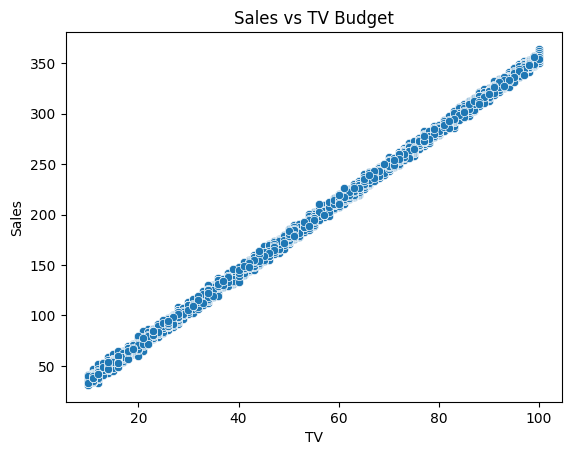

In [6]:
# Calculate correlations with Sales
correlations = df.corr()['Sales'].sort_values(ascending=False)
print("Correlations with Sales:\n", correlations)

# Visualize the strongest relationship
best_feature = correlations.index[1] # Index 0 is Sales itself
sns.scatterplot(x=df[best_feature], y=df['Sales'])
plt.title(f'Sales vs {best_feature} Budget')
plt.show()

### Step 4: Build the OLS Regression Model
Since TV has the highest correlation with Sales (~0.999), it is selected as the independent variable. We use `statsmodels` to fit the Ordinary Least Squares (OLS) model.

In [7]:
# Define independent (X) and dependent (y) variables
X = df['TV']
y = df['Sales']

# Add constant for the intercept
X_with_constant = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X_with_constant).fit()

# Print summary statistics
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:45:34   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

### Step 5: Diagnostic Plots
To validate our regression model, we must test three core assumptions: Linearity, Normality of Residuals, and Homoscedasticity (equal variance of residuals).

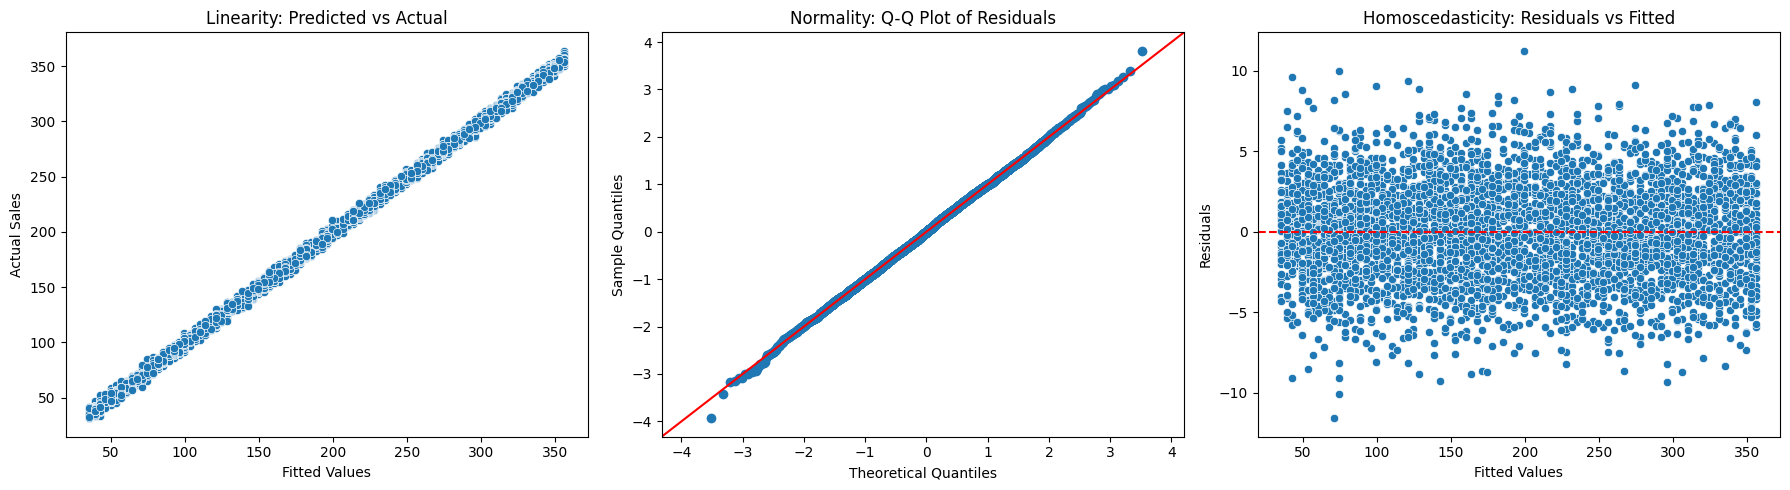

In [8]:
# Extract fitted values and residuals
fitted_values = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Linearity: Predicted vs Actual
sns.scatterplot(x=fitted_values, y=y, ax=axes[0])
axes[0].set_title("Linearity: Predicted vs Actual")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Actual Sales")

# 2. Normality of Residuals: Q-Q Plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title("Normality: Q-Q Plot of Residuals")

# 3. Homoscedasticity: Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title("Homoscedasticity: Residuals vs Fitted")
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Step 6: Business Interpretation & ROI Recommendation

**Statistical Interpretations:**
* **R-squared (0.999):** 99.9% of the variance in Sales is explained by the TV marketing budget. This indicates a near-perfect predictive fit.
* **Coefficient (3.5615):** For every additional $1 unit spent on TV advertising, Sales increase by approximately 3.56 units.
* **p-value (0.000):** The p-value for the TV coefficient is practically zero (p < 0.05), proving that the relationship between TV budget and Sales is statistically significant, not due to random chance.

**Business Recommendation:**
Based on the data, the **TV** marketing channel provides an overwhelming and highly predictable Return on Investment (ROI). The extreme correlation and standard 3.56x multiplier mean that budget allocation should aggressively prioritize TV advertising over Radio and Social Media to maximize total Sales output.